<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#14b8a6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 40 · Probability Distributions</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Sampling Distributions &amp; the CLT 🌉</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">A sample mean is itself random. This notebook builds the sampling distribution of the mean, watches the Central Limit Theorem turn a skewed population normal, measures the standard error and the square-root law, checks confidence-interval coverage, and connects it all to mini-batch gradients.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(40)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
TEAL="#0d9488"; PINK="#db2777"; AMBER="#d97706"
print("ready")

ready


<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 1 · THE SAMPLING DISTRIBUTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A statistic is itself random</div>
<div style="color:#4a5578;margin-top:6px">Draw a sample, compute its mean, and you get one number. Draw another sample and you get a slightly different one. The distribution of those means across many samples is the SAMPLING DISTRIBUTION of the mean.</div>
</div>

In [2]:
# a skewed population: exponential with mean 2, sd 2
pop_mean, pop_sd = 2.0, 2.0
n = 30
means = np.array([rng.exponential(2.0, size=n).mean() for _ in range(50_000)])
print(f"population:  mean = {pop_mean:.3f}, sd = {pop_sd:.3f}")
print(f"sample means: mean = {means.mean():.3f}, sd = {means.std():.3f}")
print(f"theory: SE = sd/sqrt(n) = {pop_sd/np.sqrt(n):.3f}")

population:  mean = 2.000, sd = 2.000
sample means: mean = 1.997, sd = 0.364
theory: SE = sd/sqrt(n) = 0.365


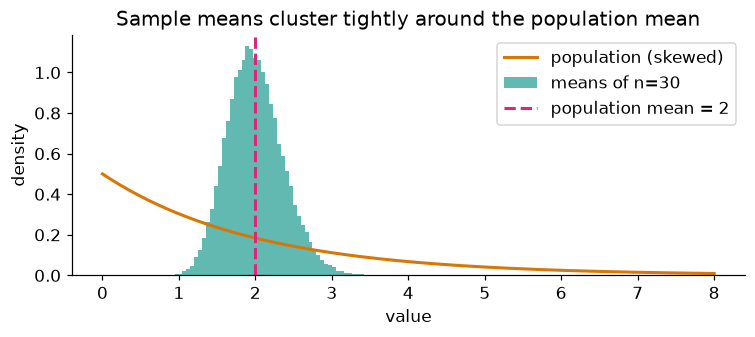

In [3]:
fig,ax=plt.subplots(figsize=(7,3.2))
xs=np.linspace(0,8,200)
ax.plot(xs, np.exp(-xs/2)/2, color=AMBER, lw=2, label="population (skewed)")
ax.hist(means, bins=60, density=True, color=TEAL, alpha=0.65, label=f"means of n={n}")
ax.axvline(pop_mean, color=PINK, ls="--", lw=2, label="population mean = 2")
ax.set_xlabel("value"); ax.set_ylabel("density"); ax.set_title("Sample means cluster tightly around the population mean"); ax.legend()
plt.tight_layout(); plt.show()

The population is heavily skewed, yet the sample means form a tight, symmetric mound centered exactly on the population mean of 2. The means vary far less than individual values, their spread is the **standard error**, sd/sqrt(n) = 0.365.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 2 · THE CENTRAL LIMIT THEOREM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Normality emerges from chaos</div>
<div style="color:#4a5578;margin-top:6px">The CLT: as the sample size n grows, the sampling distribution of the mean becomes normal, NO MATTER how non-normal the population is. Watch it happen from a wildly skewed start.</div>
</div>

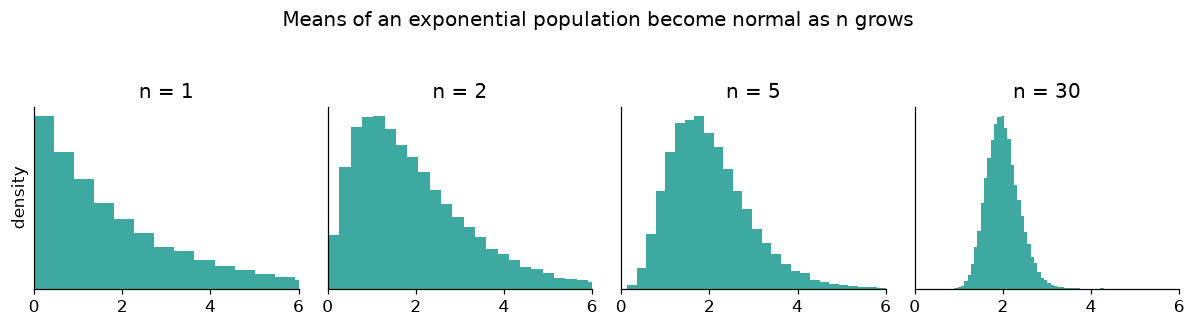

In [4]:
fig,axes=plt.subplots(1,4,figsize=(11,2.8))
for ax,n in zip(axes,[1,2,5,30]):
    m=np.array([rng.exponential(2.0,size=n).mean() for _ in range(40_000)])
    ax.hist(m,bins=45,density=True,color=TEAL,alpha=0.8)
    ax.set_title(f"n = {n}"); ax.set_yticks([]); ax.set_xlim(0,6)
axes[0].set_ylabel("density")
fig.suptitle("Means of an exponential population become normal as n grows", y=1.05)
plt.tight_layout(); plt.show()

At n=1 the distribution of "means" is just the skewed population itself. By n=5 it is already more symmetric, and by n=30 it is a clean bell. This is the **Central Limit Theorem**: averages of many independent draws are approximately normal, which is why the normal distribution is everywhere and why so much of inference can lean on it.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 3 · STANDARD ERROR &amp; THE sqrt(N) LAW</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Precision costs data</div>
<div style="color:#4a5578;margin-top:6px">The standard error SE = sigma/sqrt(n) measures how much a sample mean wobbles. Because of the square root, halving the error requires FOUR times the data.</div>
</div>

In [5]:
sigma = 2.0
for n in [25, 100, 400, 1600]:
    print(f"n={n:5d}:  SE = sigma/sqrt(n) = {sigma/np.sqrt(n):.4f}")
print("\nQuadrupling n (25 -> 100 -> 400 -> 1600) halves the SE each step.")

n=   25:  SE = sigma/sqrt(n) = 0.4000
n=  100:  SE = sigma/sqrt(n) = 0.2000
n=  400:  SE = sigma/sqrt(n) = 0.1000
n= 1600:  SE = sigma/sqrt(n) = 0.0500

Quadrupling n (25 -> 100 -> 400 -> 1600) halves the SE each step.


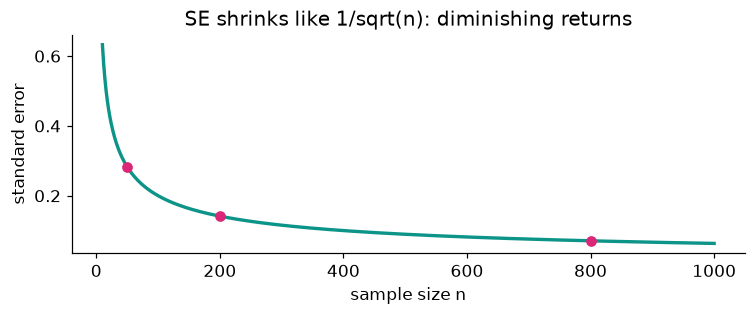

In [6]:
ns=np.arange(10,1001)
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(ns, sigma/np.sqrt(ns), color=TEAL, lw=2.2)
for n in [50,200,800]: ax.scatter(n, sigma/np.sqrt(n), color=PINK, zorder=3)
ax.set_xlabel("sample size n"); ax.set_ylabel("standard error"); ax.set_title("SE shrinks like 1/sqrt(n): diminishing returns")
plt.tight_layout(); plt.show()

The standard error falls steeply at first, then crawls: going from n=50 to n=200 helps a lot, but n=800 to n=950 barely moves it. This **diminishing return** is the central economic fact of data collection, and the reason "just get more data" eventually stops paying off.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 4 · CONFIDENCE-INTERVAL COVERAGE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why 1.96 x SE works</div>
<div style="color:#4a5578;margin-top:6px">Because the sample mean is approximately normal, the interval x_bar +/- 1.96 x SE should capture the true mean about 95% of the time. Let us verify by building thousands of intervals.</div>
</div>

In [7]:
true_mu, sigma, n = 2.0, 2.0, 50
SE = sigma/np.sqrt(n)
covered = 0; trials = 20_000
for _ in range(trials):
    xbar = rng.exponential(2.0, size=n).mean()
    lo, hi = xbar - 1.96*SE, xbar + 1.96*SE
    if lo <= true_mu <= hi: covered += 1
print(f"95% CIs that captured the true mean: {covered/trials*100:.1f}%")

95% CIs that captured the true mean: 95.3%


About 95% of the intervals contain the true mean, exactly as advertised. This is the bridge the CLT builds: it lets us attach a margin of error, x_bar +/- 1.96 x SE, to a single sample, the foundation of the confidence intervals and hypothesis tests in the chapters ahead.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 5 · MINI-BATCH GRADIENTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The CLT inside the training loop</div>
<div style="color:#4a5578;margin-top:6px">A mini-batch gradient is the AVERAGE of per-example gradients, so it is a sample mean, with standard error sigma/sqrt(batch). Bigger batches give less noisy gradient estimates.</div>
</div>

In [8]:
# per-example gradient component: true value g with noise
true_g, noise_sd = 0.50, 3.0
for batch in [8, 32, 128, 512]:
    ests = np.array([(true_g + rng.normal(0, noise_sd, size=batch)).mean() for _ in range(5_000)])
    print(f"batch={batch:4d}:  gradient estimate SE = {ests.std():.4f}  (theory {noise_sd/np.sqrt(batch):.4f})")

# a test-accuracy estimate is also a sample mean: SE = sqrt(p(1-p)/n)
p, n_test = 0.92, 2000
print(f"\ntest accuracy 0.92 on {n_test} examples: SE = {np.sqrt(p*(1-p)/n_test):.4f}, margin +/- {1.96*np.sqrt(p*(1-p)/n_test):.3f}")

batch=   8:  gradient estimate SE = 1.0643  (theory 1.0607)
batch=  32:  gradient estimate SE = 0.5299  (theory 0.5303)
batch= 128:  gradient estimate SE = 0.2674  (theory 0.2652)
batch= 512:  gradient estimate SE = 0.1335  (theory 0.1326)

test accuracy 0.92 on 2000 examples: SE = 0.0061, margin +/- 0.012


A mini-batch gradient is a noisy estimate of the true gradient, and its noise shrinks like 1/sqrt(batch), pure standard error. That is why large batches give smoother updates (and why the noise of small batches can actually help generalization). The same formula puts an honest margin of error on a reported accuracy: 0.92 on 2,000 examples is really 0.92 +/- 0.012.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You built the sampling distribution of the mean, watched the CLT turn a skewed population normal, measured the standard error and its square-root law, verified 95% interval coverage, and saw the very same math govern mini-batch gradients. The CLT is the bridge from probability to inference.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>